# BUCSS 2026
## AI Session Hands-On Part 2: Data Splitting and Model training

In this notebook you will:
- Prepare data for a target model
- Train statistical and machine learning models
- Get insights from trained models

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from xgboost import XGBClassifier


#These are internal
from scripts.splitting_and_training import split_data 

df = pd.read_parquet("../dataframes_for_training/dortmund_training.parquet")

First we need to decide if we want every column in our dataframe as a feature in our ML model. 

In [9]:
df.columns



Index(['station_id', 'latitude', 'longitude', 'datetime_utc',
       'air_temperature', 'bh_nearest', 'bh_buf50', 'bh_buf100', 'bh_buf250',
       'bh_buf500', 'bh_buf750', 'bh_buf1000', 'tcd_nearest', 'tcd_buf50',
       'tcd_buf100', 'tcd_buf250', 'tcd_buf500', 'tcd_buf750', 'tcd_buf1000',
       'imp_nearest', 'imp_buf50', 'imp_buf100', 'imp_buf250', 'imp_buf500',
       'imp_buf750', 'imp_buf1000', 'dtm_nearest', 'lcz_nearest', 'LCZ_1',
       'LCZ_2', 'LCZ_3', 'LCZ_4', 'LCZ_5', 'LCZ_6', 'LCZ_7', 'LCZ_8', 'LCZ_9',
       'LCZ_10', 'LCZ_11', 'LCZ_12', 'LCZ_13', 'LCZ_14', 'LCZ_15', 'LCZ_16',
       'LCZ_17', 't2m', 'd2m', 'ssrd', 'tp', 'u10', 'v10', 'sp', 'ssrd_deac',
       'tp_deac', 'rh', 'wspd', 't2m_corr'],
      dtype='object')

In [10]:
df_training = df.drop(columns=["air_temperature", 
                        "lcz_nearest", "datetime_utc","u10", 
                        "v10", "ssrd", "tp", "d2m", "t2m"]).copy()

df["temp_diff"] = df["air_temperature"] - df["t2m_corr"]

target_var = df["temp_diff"]  #df["air_temperature"]


In [11]:
X = df_training
y = target_var
mode = "block_spatial" # "random", "random_spatial". "block_spatial"

In [12]:
X_train, X_val, y_train, y_val = split_data(X, y, mode) 

In [13]:
params = {
    "eta": 0.3,
    "max_depth": 10,
    "colsample_bytree": 0.8,
    "subsample": 0.8,
    "gamma": 1.0,
    "min_child_weight": 1.0,
    "reg_lambda": 1.0,
    "reg_alpha": 0.0
}

features = list(X_train.columns)

dtrain = xgb.DMatrix(X_train, label=y_train, feature_names=features)
dval = xgb.DMatrix(X_test, label=y_test, feature_names=features)
watchlist = [(dtrain, "train"), (dval, "valid")]

params["objective"] = "reg:squarederror"
params["eval_metric"] = "rmse" 
model = xgb.train(params, dtrain, num_boost_round=1000, evals=watchlist, 
                    early_stopping_rounds=10, verbose_eval=15)


y_pred = model.predict(dval)

[0]	train-rmse:1.38386	valid-rmse:1.37413
[15]	train-rmse:0.84012	valid-rmse:0.86369
[30]	train-rmse:0.69847	valid-rmse:0.72968
[45]	train-rmse:0.60621	valid-rmse:0.64521
[60]	train-rmse:0.53871	valid-rmse:0.58525
[75]	train-rmse:0.50112	valid-rmse:0.55131
[90]	train-rmse:0.47500	valid-rmse:0.52931
[105]	train-rmse:0.46804	valid-rmse:0.52336
[120]	train-rmse:0.45718	valid-rmse:0.51404
[135]	train-rmse:0.45476	valid-rmse:0.51195
[150]	train-rmse:0.44843	valid-rmse:0.50688
[165]	train-rmse:0.44662	valid-rmse:0.50534
[180]	train-rmse:0.44040	valid-rmse:0.50048
[195]	train-rmse:0.44040	valid-rmse:0.50048
[210]	train-rmse:0.43979	valid-rmse:0.49988
[219]	train-rmse:0.43979	valid-rmse:0.49988


In [7]:
from sklearn.metrics import mean_squared_error, r2_score

t2m_corr_test = df.loc[y_test.index, "t2m_corr"]

y_rec = t2m_corr_test.values + y_test.values          # observed temp reconstructed
y_pred_rec = t2m_corr_test.values + y_pred   

rmse = np.sqrt(mean_squared_error(y_rec, y_pred_rec))
r2   = r2_score(y_rec, y_pred_rec)
print(f"RMSE: {rmse:.3f} °C   R²: {r2:.3f}")

RMSE: 0.575 °C   R²: 0.994


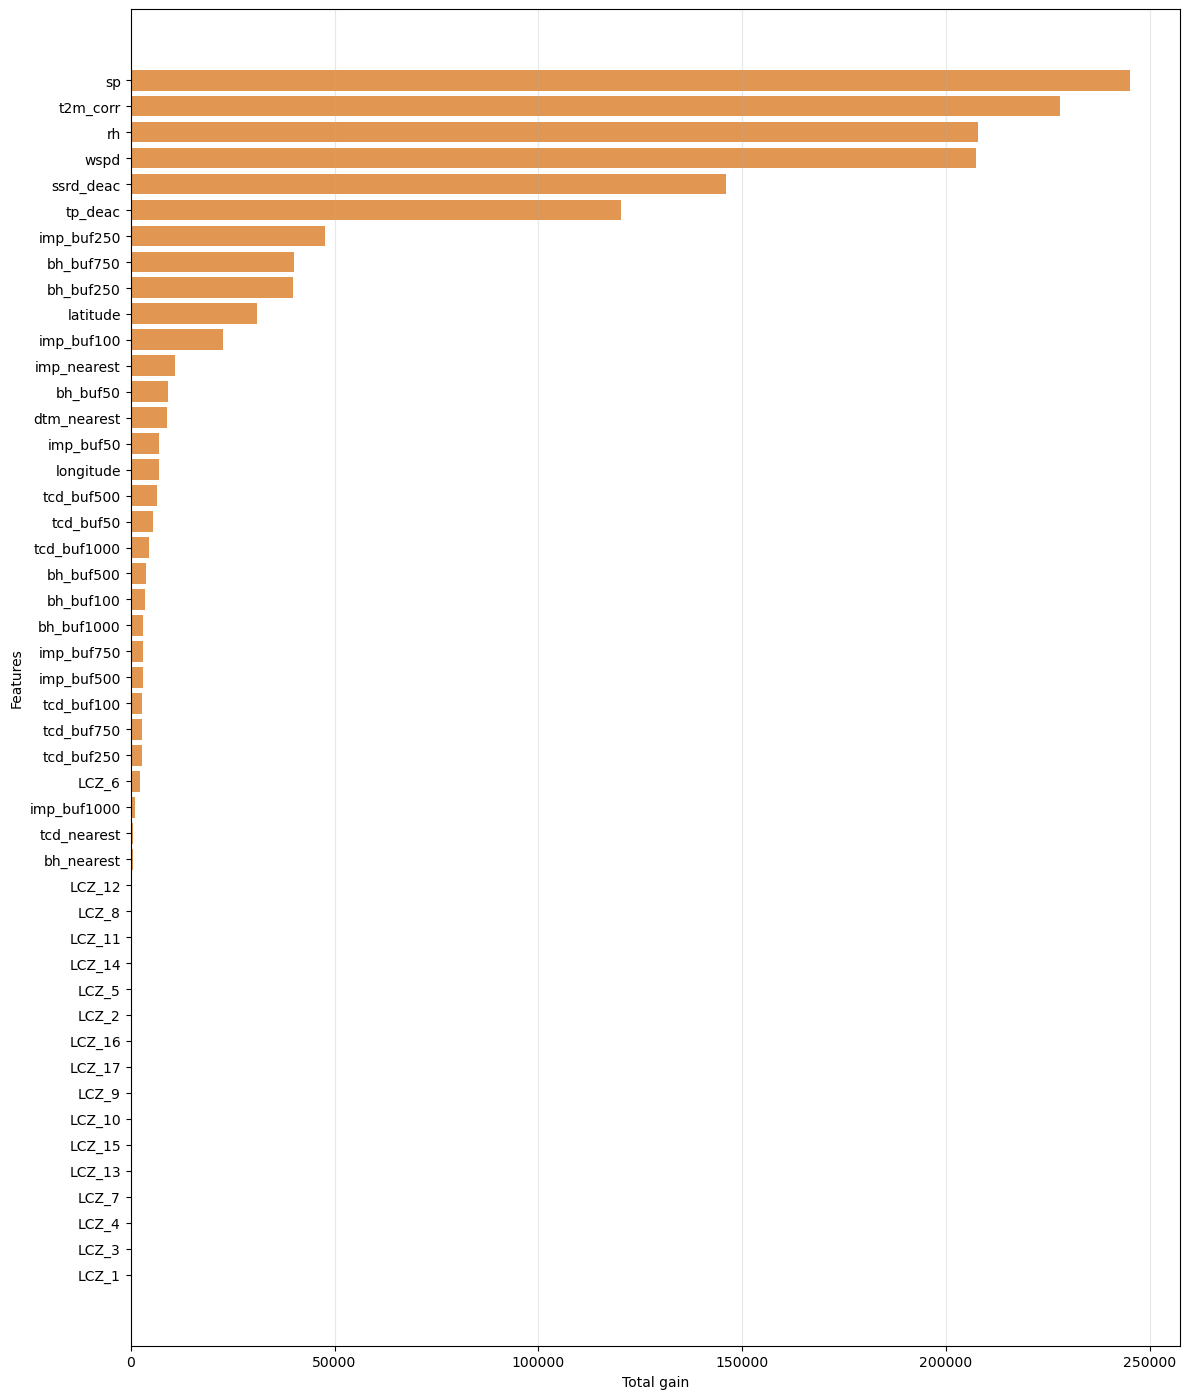


Feature importances (sorted):
sp: 245095.875000
t2m_corr: 227860.656250
rh: 207892.750000
wspd: 207346.937500
ssrd_deac: 146060.828125
tp_deac: 120316.109375
imp_buf250: 47747.980469
bh_buf750: 40146.835938
bh_buf250: 39781.742188
latitude: 31040.525391
imp_buf100: 22595.296875
imp_nearest: 10953.941406
bh_buf50: 9056.040039
dtm_nearest: 8815.414062
imp_buf50: 7049.630859
longitude: 7044.272461
tcd_buf500: 6382.678711
tcd_buf50: 5482.478516
tcd_buf1000: 4458.526367
bh_buf500: 3756.200195
bh_buf100: 3471.807617
bh_buf1000: 3131.638672
imp_buf750: 2940.955811
imp_buf500: 2911.781982
tcd_buf100: 2811.096924
tcd_buf750: 2783.580566
tcd_buf250: 2731.135010
LCZ_6: 2173.448975
imp_buf1000: 1115.153320
tcd_nearest: 603.669189
bh_nearest: 585.911926
LCZ_12: 192.364059
LCZ_8: 89.579224
LCZ_11: 41.574802
LCZ_14: 37.731159
LCZ_5: 30.293697
LCZ_2: 22.617752
LCZ_16: 0.000000
LCZ_17: 0.000000
LCZ_9: 0.000000
LCZ_10: 0.000000
LCZ_15: 0.000000
LCZ_13: 0.000000
LCZ_7: 0.000000
LCZ_4: 0.000000
LCZ_3: 0.

In [25]:
import cmcrameri.cm as cmc

def importance(model):
    # For models trained with xgb.train() and DMatrix with feature_names
    feature_names = model.feature_names
    cmap = cmc.batlow
    # sample two colors away from extremes for clarity
    predicted_color = cmap(0.7)
        # Get importance scores (you can choose different types)
    importance_dict = model.get_score(importance_type='total_gain')  # or 'gain', 'cover'
    
    # Convert to arrays, ensuring order matches feature_names
    importances = np.array([importance_dict.get(fname, 0.0) for fname in feature_names])

    sorted_indices = np.argsort(importances)
    sorted_importances = importances[sorted_indices]
    sorted_features = [feature_names[i] for i in sorted_indices]

    # Create the horizontal bar plot
    plt.figure(figsize=(12, max(8, len(sorted_features) * 0.3)))
    bars = plt.barh(range(len(sorted_features)), sorted_importances, 
                    color=predicted_color,
                    #  alpha=0.7
                    )

    # Customize the plot
    plt.yticks(range(len(sorted_features)), sorted_features)
    plt.xlabel('Total gain')
    plt.ylabel('Features')
    # plt.title('XGBoost Feature Importances')
    plt.grid(axis='x', alpha=0.3)

        # # Add value labels on bars
        # for i, (bar, v) in enumerate(zip(bars, sorted_importances)):
        #     plt.text(v + max(sorted_importances) * 0.01, i, f'{v:.3f}', 
        #             va='center', fontsize=9)

    plt.tight_layout()
    plt.show()

    print("\nFeature importances (sorted):")
    for feat, val in zip(sorted_features[::-1], sorted_importances[::-1]):
        print(f"{feat}: {val:.6f}")
    
importance(model)

Which variables should be kept ? Once we've figured that out, we should also determine what target variable we want to train for...

In [43]:
df_training = df.drop(columns=["air_temperature"]).copy()
target_var = df["air_temperature"]

import numpy as np

df["temp_diff"] = df["air_temperature"] - df["t2m_corr"]

# cyclical time features
hod = df["datetime_utc"].dt.hour                    # 0-23
doy = df["datetime_utc"].dt.dayofyear               # 1-365/366

df["tod_sin"] = np.sin(2 * np.pi * hod / 24)
df["tod_cos"] = np.cos(2 * np.pi * hod / 24)
df["doy_sin"] = np.sin(2 * np.pi * doy / 365)
df["doy_cos"] = np.cos(2 * np.pi * doy / 365)


In [45]:

import statsmodels.api as sm

def forward_select(df, y_col, candidates, forced=(), threshold=0.01):
    """Greedily add predictors. `forced` predictors are always kept, selection adds on top."""
    selected = list(forced)                          # start with the forced ones
    remaining = [c for c in candidates if c not in selected]
    y = df[y_col]

    # baseline R² with only the forced predictors in
    if selected:
        X = sm.add_constant(df[selected])
        current_adj_r2 = sm.OLS(y, X).fit().rsquared_adj
        print(f"forced {selected}  adj_R²={current_adj_r2:.4f}")
    else:
        current_adj_r2 = 0.0

    while remaining:
        best_adj_r2 = current_adj_r2
        best_pred = None
        for cand in remaining:
            X = sm.add_constant(df[selected + [cand]])
            adj_r2 = sm.OLS(y, X).fit().rsquared_adj
            if adj_r2 > best_adj_r2:
                best_adj_r2 = adj_r2
                best_pred = cand

        if best_pred is None or (best_adj_r2 - current_adj_r2) < threshold:
            break

        selected.append(best_pred)
        remaining.remove(best_pred)
        current_adj_r2 = best_adj_r2
        print(f"added {best_pred:20s} adj_R²={best_adj_r2:.4f}")

    return selected

candidates = [c for c in df.columns
              if c not in ("station_id", "datetime_utc", "air_temperature", "temp_diff",
                           "lcz_nearest", "u10", "v10", "ssrd", "tp", "d2m")
                           and not c.startswith("LCZ_")]

forced = ["tod_sin", "tod_cos", "doy_sin", "doy_cos"]
selected_predictors = forward_select(df, "temp_diff", candidates, forced=forced)

forced ['tod_sin', 'tod_cos', 'doy_sin', 'doy_cos']  adj_R²=0.0726
added imp_buf250           adj_R²=0.1285


In [46]:
import statsmodels.api as sm

X = sm.add_constant(df[selected_predictors])   # predictors + intercept column
y = df["temp_diff"]

model = sm.OLS(y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:              temp_diff   R-squared:                       0.129
Model:                            OLS   Adj. R-squared:                  0.129
Method:                 Least Squares   F-statistic:                 1.820e+04
Date:                Mon, 10 Aug 2026   Prob (F-statistic):               0.00
Time:                        11:07:24   Log-Likelihood:            -1.0875e+06
No. Observations:              617036   AIC:                         2.175e+06
Df Residuals:                  617030   BIC:                         2.175e+06
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0916      0.004    -23.961      0.0

In [18]:
# --- test on ONE hour first ---
hour = 2
df_h = df[df["datetime_utc"].dt.hour == hour].copy()

candidates = [c for c in df.columns
              if c not in ("station_id", "datetime_utc", "air_temperature", "temp_diff",
                           "lcz_nearest", "u10", "v10", "ssrd", "tp", "d2m")]

selected_predictors = forward_select(df_h, "temp_diff", candidates)   # df_h, not df

added imp_buf250           adj_R²=0.1147
added t2m_corr             adj_R²=0.1473
added rh                   adj_R²=0.1612
added bh_buf500            adj_R²=0.1748
added t2m                  adj_R²=0.1885


In [22]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

scaled_array = scaler.fit_transform(df[candidates])     # fit AND transform, on the candidates

scaled_array

array([[-0.24062922, -0.16835564, -0.31395558, ...,  0.7763251 ,
         2.8338827 , -0.93804841],
       [-0.24062922, -0.16835564, -0.31395558, ...,  0.63899577,
         2.79831207, -0.89731414],
       [-0.24062922, -0.16835564, -0.31395558, ...,  0.40827625,
         2.78044408, -0.88780765],
       ...,
       [-1.66904815, -1.09726594, -0.31395558, ...,  1.22325797,
         0.96186582, -1.38857395],
       [-1.66904815, -1.09726594, -0.31395558, ...,  1.16782677,
         1.09760394, -1.44592457],
       [-1.66904815, -1.09726594, -0.31395558, ...,  1.14649497,
         1.22193882, -1.49184382]], shape=(617036, 48))

In [29]:
jja = df[df["datetime_utc"].dt.month.isin([6, 7, 8])].copy()
jja["hour"] = jja["datetime_utc"].dt.hour

# mean temp_diff per station per hour (geo predictors are constant per station, take first)
agg = {c: "first" for c in candidates}      # predictors: same for all rows of a station
agg["temp_diff"] = "mean"                    # target: average over all JJA days
station_hour = (jja.groupby(["station_id", "hour"])
                   .agg(agg)
                   .reset_index())


geo_predictors = [c for c in candidates
                  if c.startswith(("bh_", "tcd_", "imp_")) or c in ("dtm", "t2m_corr")]

results = {}
for hour in range(24):
    sub = station_hour[station_hour["hour"] == hour]
    print(f"\n=== hour {hour:02d}  ({len(sub)} stations) ===")
    selected = forward_select(sub, "temp_diff", geo_predictors, threshold=0.001)
    results[hour] = selected


=== hour 00  (76 stations) ===
added imp_buf250           adj_R²=0.7148
added bh_buf500            adj_R²=0.7371
added tcd_buf500           adj_R²=0.7419
added tcd_buf50            adj_R²=0.7505
added bh_buf100            adj_R²=0.7604
added t2m_corr             adj_R²=0.7660
added imp_buf50            adj_R²=0.7702
added tcd_buf250           adj_R²=0.7780
added imp_buf1000          adj_R²=0.7967
added tcd_buf1000          adj_R²=0.7997
added tcd_buf750           adj_R²=0.8029
added imp_buf750           adj_R²=0.8098
added bh_buf250            adj_R²=0.8116

=== hour 01  (76 stations) ===
added imp_buf250           adj_R²=0.7110
added bh_buf500            adj_R²=0.7347
added imp_buf50            adj_R²=0.7377
added imp_buf1000          adj_R²=0.7392

=== hour 02  (76 stations) ===
added imp_buf250           adj_R²=0.7128
added bh_buf500            adj_R²=0.7392
added imp_buf50            adj_R²=0.7415
added tcd_buf50            adj_R²=0.7440
added tcd_buf250           adj_R²=0.7688
ad

In [32]:
results = {}
for hour in range(24):
    sub = station_hour[station_hour["hour"] == hour]
    selected = forward_select(sub, "temp_diff", geo_predictors, threshold=0.001)
    if selected:
        X = sm.add_constant(sub[selected])
        r2 = sm.OLS(sub["temp_diff"], X).fit().rsquared_adj
    else:
        r2 = 0.0
    results[hour] = {"predictors": selected, "adj_r2": r2}
    print(f"hour {hour:02d}: adj_R²={r2:.3f}  {selected}")

hour 00: adj_R²=0.812  ['imp_buf250', 'bh_buf500', 'tcd_buf500', 'tcd_buf50', 'bh_buf100', 't2m_corr', 'imp_buf50', 'tcd_buf250', 'imp_buf1000', 'tcd_buf1000', 'tcd_buf750', 'imp_buf750', 'bh_buf250']
hour 01: adj_R²=0.739  ['imp_buf250', 'bh_buf500', 'imp_buf50', 'imp_buf1000']
hour 02: adj_R²=0.815  ['imp_buf250', 'bh_buf500', 'imp_buf50', 'tcd_buf50', 'tcd_buf250', 'imp_buf1000', 'bh_buf250', 't2m_corr', 'tcd_buf1000', 'tcd_buf750', 'imp_buf750', 'imp_nearest']
hour 03: adj_R²=0.739  ['imp_buf250', 'bh_buf500', 'imp_buf50', 'imp_buf1000']
hour 04: adj_R²=0.731  ['imp_buf250', 'bh_buf500', 'imp_buf50', 'imp_buf1000']
hour 05: adj_R²=0.721  ['imp_buf250', 'tcd_buf500', 'tcd_nearest', 'bh_buf100']
hour 06: adj_R²=0.681  ['tcd_buf500', 'imp_buf50', 't2m_corr', 'tcd_buf250', 'imp_buf1000', 'bh_buf750']
hour 07: adj_R²=0.599  ['tcd_buf50', 'tcd_buf500', 'imp_nearest', 'bh_buf100', 'imp_buf500']
hour 08: adj_R²=0.596  ['tcd_buf50', 'bh_buf100', 'imp_buf500', 'imp_nearest', 'imp_buf50', 'bh

In [35]:
import statsmodels.api as sm

hour = 3
sub = station_hour[station_hour["hour"] == hour]

selected = results[hour]["predictors"]          # <- get THIS hour's selected set
X = sm.add_constant(sub[selected])
y = sub["temp_diff"]

model = sm.OLS(y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:              temp_diff   R-squared:                       0.753
Model:                            OLS   Adj. R-squared:                  0.739
Method:                 Least Squares   F-statistic:                     54.05
Date:                Mon, 10 Aug 2026   Prob (F-statistic):           7.90e-21
Time:                        11:02:20   Log-Likelihood:                -45.614
No. Observations:                  76   AIC:                             101.2
Df Residuals:                      71   BIC:                             112.9
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const          -1.1365      0.129     -8.780      

In [26]:
selected = forward_select(station_hour, "temp_diff", candidates)

added imp_buf250           adj_R²=0.3059
added LCZ_11               adj_R²=0.3682
added rh                   adj_R²=0.4246
added ssrd_deac            adj_R²=0.5509


In [24]:
df_scaled = df.copy()
df_scaled[candidates] = scaled_array

hour = 2
df_h = df_scaled[df_scaled["datetime_utc"].dt.hour == hour].copy()



selected = forward_select(df_h, "temp_diff", candidates)

added imp_buf250           adj_R²=0.1147
added t2m_corr             adj_R²=0.1473
added rh                   adj_R²=0.1612
added bh_buf500            adj_R²=0.1748
added t2m                  adj_R²=0.1885


In [27]:
import statsmodels.api as sm

hour = 2
sub = station_hour[station_hour["hour"] == hour]

X = sm.add_constant(sub[selected_predictors])   # predictors + intercept
y = sub["temp_diff"]

model = sm.OLS(y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:              temp_diff   R-squared:                       0.810
Model:                            OLS   Adj. R-squared:                  0.797
Method:                 Least Squares   F-statistic:                     59.88
Date:                Mon, 10 Aug 2026   Prob (F-statistic):           6.30e-24
Time:                        10:55:17   Log-Likelihood:                -37.166
No. Observations:                  76   AIC:                             86.33
Df Residuals:                      70   BIC:                             100.3
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         11.7781      7.239      1.627      0.1

In [3]:
target_var = df["air_temperature"]
target_var

0         4.233333
1         4.400000
2         4.772727
3         4.800000
4         5.327273
            ...   
617031    2.819785
617032    2.644879
617033    2.293508
617034    2.135291
617035    2.019577
Name: air_temperature, Length: 617036, dtype: float64